# Phase 2: Segmentation via Clustering
## Lending Club Loan Dataset

**Tujuan fase:** menemukan pengelompokan alami peminjam dan menerjemahkan tiap kelompok menjadi profil bernama yang bermakna secara bisnis.

**Tugas:** K-Means, DBSCAN, Hierarchical; K optimal via Elbow + Silhouette; profiling tiap cluster.

**Input dari Phase 1:**
- `lending_club_pca.csv`, 9 komponen PCA -> input **K-Means & Hierarchical**.
- `lending_club_umap.csv`, 2D -> input **DBSCAN**.
- `cleaned_lending_club_no_winsorization.csv`, nilai **asli** fitur final -> untuk **profiling** yang terbaca bisnis.
- `loan_status_reference.csv`, label referensi (validasi, bukan target).

## 1: Konfigurasi & Load Data

In [57]:
import os
# Pindah ke root proyek agar path data konsisten di mana pun notebook dijalankan
for _ in range(6):
    if os.path.isdir('data'): break
    os.chdir('..')
print('working dir:', os.getcwd())

working dir: c:\Users\forme\Documents\BCA\Cawu5\LEC-data-mining\lending-club-loans


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (11, 5)
sns.set_theme(style='whitegrid', palette='viridis')
RANDOM_SEED = 42
print('Siap.')

Siap.


In [59]:
X_pca    = pd.read_csv('data/processed/lending_club_pca.csv')                          # input K-Means
profile  = pd.read_csv('data/processed/cleaned_lending_club_no_winsorization.csv')     # nilai asli (profiling)
loan_ref = pd.read_csv('data/processed/loan_status_reference.csv')['loan_status']

print('X_pca   :', X_pca.shape)
print('profile :', profile.shape, '| kolom:', list(profile.columns))
assert len(X_pca) == len(profile) == len(loan_ref), 'baris tidak selaras!'
print('Baris selaras:', len(X_pca))

X_pca   : (2260668, 9)
profile : (2260668, 12) | kolom: ['grade', 'annual_inc', 'dti', 'fico_range_low', 'revol_util', 'emp_length', 'loan_amnt', 'term', 'bc_open_to_buy', 'total_bc_limit', 'all_util', 'inq_last_6mths']
Baris selaras: 2260668


## 2: Penentuan K Optimal (Elbow + Silhouette, Uji Stabilitas)

K ditentukan dengan **Elbow (inertia)** dan **Silhouette Score**. Karena separasi lemah, metrik dari satu sample rapuh (peringkat K berbolak-balik antar-sample), jadi keduanya dievaluasi lewat **stabilitas lintas 5 sample acak**, rata-rata ± std dan berapa kali tiap K menang.

In [60]:
SAMPLE_N, N_SEEDS = 40_000, 5
K_RANGE = list(range(2, 9))
seeds = list(range(N_SEEDS))

metrics = {k: {'inertia': [], 'sil': []} for k in K_RANGE}
for sd in seeds:
    rng = np.random.RandomState(sd)
    Xs = X_pca.values[rng.choice(len(X_pca), SAMPLE_N, replace=False)]
    for k in K_RANGE:
        km = MiniBatchKMeans(n_clusters=k, random_state=sd, batch_size=10_000, n_init=5).fit(Xs)
        metrics[k]['inertia'].append(km.inertia_)
        metrics[k]['sil'].append(silhouette_score(Xs, km.labels_, sample_size=8_000, random_state=sd))

stab = pd.DataFrame({
    'inertia':    {k: np.mean(metrics[k]['inertia']) for k in K_RANGE},
    'silhouette': {k: np.mean(metrics[k]['sil']) for k in K_RANGE},
    'sil_std':    {k: np.std(metrics[k]['sil'])  for k in K_RANGE},
})
win = Counter(K_RANGE[int(np.argmax([metrics[k]['sil'][si] for k in K_RANGE]))] for si in range(N_SEEDS))

print('Rata-rata lintas', N_SEEDS, 'sample:')
print(stab.round(3).to_string())
print('\nK dengan Silhouette tertinggi per sample:', {f'K{k}': n for k, n in sorted(win.items())})

Rata-rata lintas 5 sample:
      inertia  silhouette  sil_std
2  369750.579       0.161    0.010
3  327804.919       0.137    0.013
4  305772.735       0.125    0.009
5  286092.949       0.116    0.005
6  274942.597       0.108    0.003
7  265081.757       0.109    0.005
8  256325.259       0.103    0.003

K dengan Silhouette tertinggi per sample: {'K2': 4, 'K3': 1}


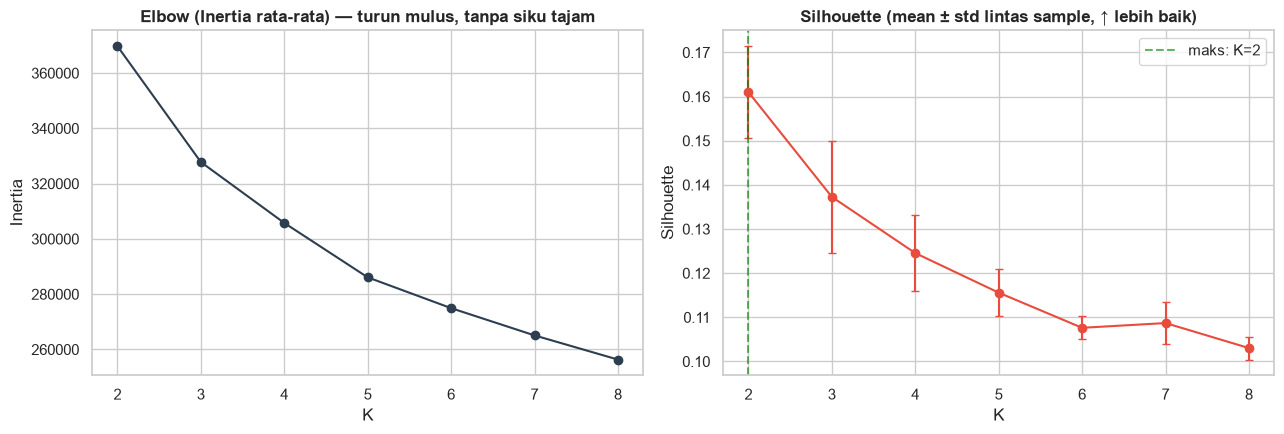

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(K_RANGE, stab['inertia'], 'o-', color='#2c3e50')
ax[0].set_title('Elbow (Inertia rata-rata) — turun mulus, tanpa siku tajam', fontweight='bold')
ax[0].set_xlabel('K'); ax[0].set_ylabel('Inertia')

ax[1].errorbar(K_RANGE, stab['silhouette'], yerr=stab['sil_std'], fmt='o-', color='#e74c3c', capsize=3)
ax[1].axvline(stab['silhouette'].idxmax(), ls='--', color='green', alpha=0.6,
              label=f"maks: K={stab['silhouette'].idxmax()}")
ax[1].set_title('Silhouette (mean ± std lintas sample, ↑ lebih baik)', fontweight='bold')
ax[1].set_xlabel('K'); ax[1].set_ylabel('Silhouette'); ax[1].legend()
plt.tight_layout(); plt.show()

### 2.1: Interpretasi & Pemilihan K

- **Silhouette** secara **robust memilih K=2** (menang di 4 dari 5 sample; rata-rata tertinggi ≈0,161).
- **Elbow** menurun mulus tanpa siku tajam, tidak menyanggah maupun menonjolkan K tertentu.
- **Validasi bisnis**: pada K=2, gap Charged-Off antar-cluster jelas (prime ≈8% vs higher-risk ≈14%).

Separasi absolut moderat (~0,16) karena profil finansial bersifat kontinu (spektrum risiko), bukan gugus terpisah tegas, ini karakteristik data, bukan kegagalan metode. **K=2 dipilih** sebagai optimum objektif: didukung Silhouette lintas sample + prinsip parsimoni + validasi eksternal.

*(K=3 tetap alternatif sah bila diinginkan profil lebih granular, namun tidak didukung metrik secara konsisten pada uji stabilitas lintas sample, sehingga K=2 dipertahankan.)*

In [62]:
K_FINAL = 2   # optimum objektif (Silhouette robust lintas sample); lihat 2.1
print(f'K_FINAL = {K_FINAL} | silhouette rata2 = {stab.loc[K_FINAL, "silhouette"]:.3f} '
      f'(± {stab.loc[K_FINAL, "sil_std"]:.3f})')

K_FINAL = 2 | silhouette rata2 = 0.161 (± 0.010)


## 3: Fit K-Means Final (Data Penuh)

`MiniBatchKMeans` dipakai agar efisien pada 2,26 juta baris (varian K-Means setara untuk data besar), lalu label ditetapkan ke seluruh entitas.

In [63]:
kmeans = MiniBatchKMeans(n_clusters=K_FINAL, random_state=RANDOM_SEED,
                         batch_size=10_000, n_init=10)
labels = kmeans.fit_predict(X_pca.values)
profile = profile.copy()
profile['cluster'] = labels

sizes = pd.Series(labels).value_counts().sort_index()
print('Ukuran cluster:')
for c, n in sizes.items():
    print(f'  Cluster {c}: {n:>10,} ({n/len(labels)*100:5.1f}%)')

Ukuran cluster:
  Cluster 0:  1,407,028 ( 62.2%)
  Cluster 1:    853,640 ( 37.8%)


### 3.1: Sebaran Cluster (Proyeksi PCA)

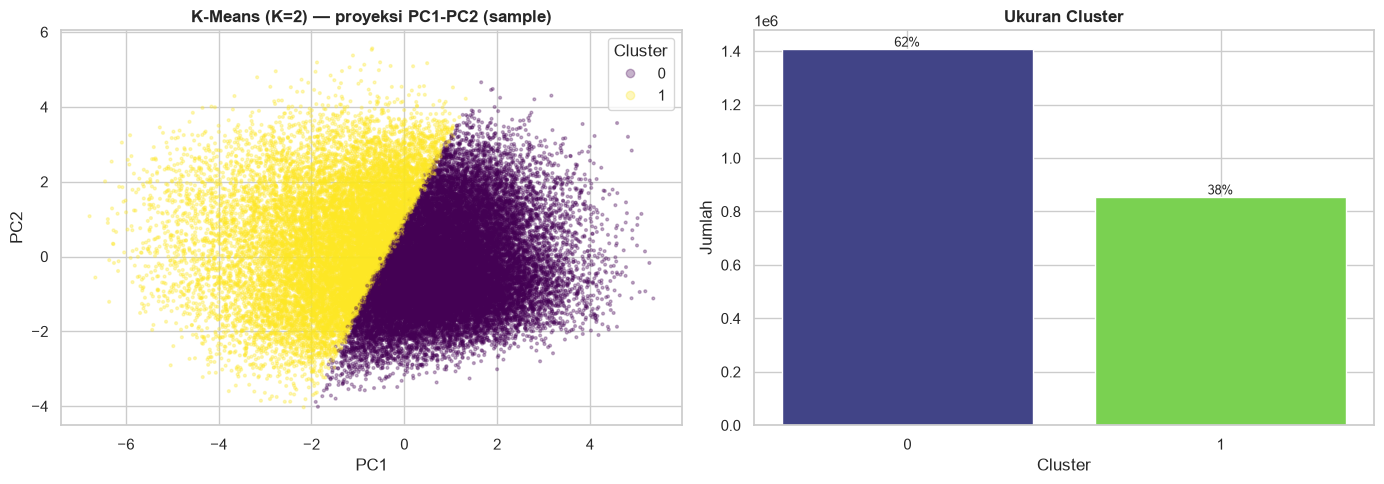

In [64]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
vidx = np.random.RandomState(RANDOM_SEED).choice(len(X_pca), 40_000, replace=False)
sc = ax[0].scatter(X_pca.values[vidx, 0], X_pca.values[vidx, 1],
                   c=labels[vidx], cmap='viridis', s=4, alpha=0.3)
ax[0].set_xlabel('PC1'); ax[0].set_ylabel('PC2')
ax[0].set_title(f'K-Means (K={K_FINAL}) — proyeksi PC1-PC2 (sample)', fontweight='bold')
ax[0].legend(*sc.legend_elements(), title='Cluster', loc='best')

ax[1].bar(sizes.index.astype(str), sizes.values, color=plt.cm.viridis(np.linspace(0.2, 0.8, K_FINAL)))
ax[1].set_title('Ukuran Cluster', fontweight='bold'); ax[1].set_xlabel('Cluster'); ax[1].set_ylabel('Jumlah')
for i, v in enumerate(sizes.values):
    ax[1].text(i, v, f'{v/len(labels)*100:.0f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

### 3.2: Kualitas Divisi & Profil per Cluster

Tiga sudut pandang: (1) sebaran di ruang PCA, (2) **silhouette plot** (lebar pita = kualitas, ekor negatif = anggota borderline), dan (3) **bar chart perbandingan fitur** (rata-rata di-z-score), cara yang jauh lebih jelas menilai pemisahan daripada scatter 2-fitur, karena clustering memakai banyak dimensi sekaligus.

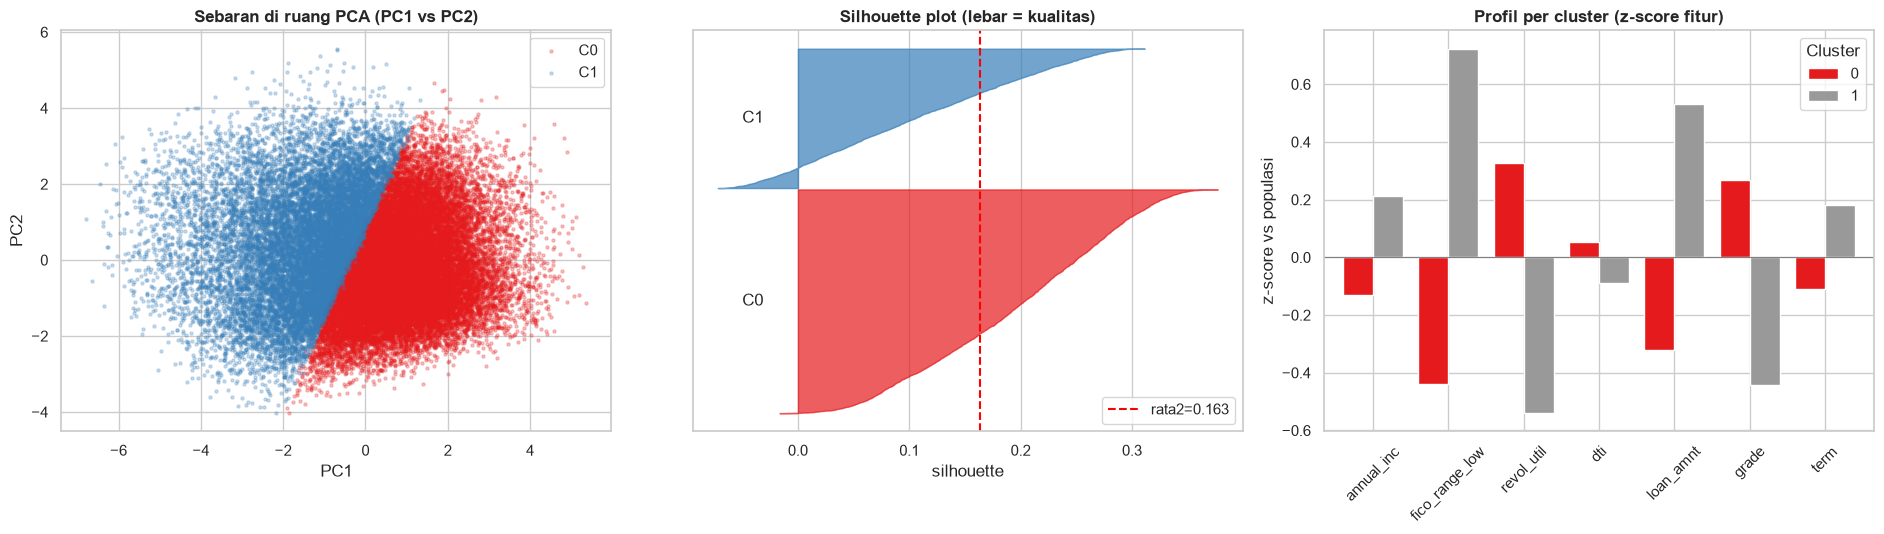

Rata-rata silhouette (sample): 0.163


In [65]:
rng_v = np.random.RandomState(RANDOM_SEED)
N_VIZ = 40_000
vi = rng_v.choice(len(X_pca), N_VIZ, replace=False)
Xv = X_pca.values[vi]; lv = labels[vi]
cmap = plt.cm.Set1

fig, ax = plt.subplots(1, 3, figsize=(19, 5.5))
for c in range(K_FINAL):
    m = lv == c
    ax[0].scatter(Xv[m, 0], Xv[m, 1], s=5, alpha=0.25, color=cmap(c), label=f'C{c}')
ax[0].set_title('Sebaran di ruang PCA (PC1 vs PC2)', fontweight='bold')
ax[0].set_xlabel('PC1'); ax[0].set_ylabel('PC2'); ax[0].legend()

s = 8000; si = rng_v.choice(len(Xv), s, replace=False)
sv = silhouette_samples(Xv[si], lv[si]); avg = sv.mean()
y = 10
for c in range(K_FINAL):
    vals = np.sort(sv[lv[si] == c]); yh = len(vals)
    ax[1].fill_betweenx(np.arange(y, y + yh), 0, vals, color=cmap(c), alpha=0.7)
    ax[1].text(-0.05, y + yh / 2, f'C{c}', va='center'); y += yh + 30
ax[1].axvline(avg, color='red', ls='--', label=f'rata2={avg:.3f}')
ax[1].set_title('Silhouette plot (lebar = kualitas)', fontweight='bold')
ax[1].set_xlabel('silhouette'); ax[1].set_yticks([]); ax[1].legend()

# Profil per cluster: z-score vs populasi -> makin jauh dari 0 = makin membedakan
feat = [f for f in ['annual_inc','fico_range_low','revol_util','dti','loan_amnt','grade','term']
        if f in profile.columns]
means = profile.groupby('cluster')[feat].mean()
z = (means - profile[feat].mean()) / profile[feat].std()
z.T.plot(kind='bar', ax=ax[2], colormap='Set1', width=0.8)
ax[2].axhline(0, color='gray', lw=0.8)
ax[2].set_title('Profil per cluster (z-score fitur)', fontweight='bold')
ax[2].set_ylabel('z-score vs populasi'); ax[2].set_xlabel('')
ax[2].tick_params(axis='x', rotation=45); ax[2].legend(title='Cluster')
plt.tight_layout(); plt.show()
print(f'Rata-rata silhouette (sample): {avg:.3f}')

## 4: Profil Awal Cluster (Nilai Asli)

Rata-rata fitur kunci per cluster memakai **nilai asli** (income dolar, dti/fico asli), basis interpretasi bisnis & penamaan profil di tahap profiling penuh.

In [66]:
key = [c for c in ['grade','annual_inc','dti','fico_range_low','revol_util',
                   'emp_length','loan_amnt','term'] if c in profile.columns]
prof = profile.groupby('cluster')[key].mean().round(1)
prof['size_%'] = (sizes / len(labels) * 100).round(1).values
prof

,grade,annual_inc,dti,fico_range_low,revol_util,emp_length,loan_amnt,term,size_%
cluster,,,,,,,,,
0,3.0,63474.5,19.6,684.1,58.4,5.7,12086.5,41.7,62.2
1,2.1,101921.8,17.5,722.5,37.0,6.4,19926.6,44.9,37.8


In [67]:
# Validasi silang dengan loan_status (referensi, bukan target): % Charged Off per cluster
xtab = pd.crosstab(labels, loan_ref, normalize='index') * 100
co = [c for c in xtab.columns if 'Charged Off' in c]
if co:
    print('% Charged Off per cluster (indikasi risiko aktual):')
    print(xtab[co].round(1).to_string())

% Charged Off per cluster (indikasi risiko aktual):
loan_status  Charged Off  Does not meet the credit policy. Status:Charged Off
row_0                                                                        
0                   14.4                                                  0.1
1                    7.7                                                  0.0


### 4.1: Simpan Label Cluster

In [68]:
pd.DataFrame({'kmeans_cluster': labels}).to_csv('data/processed/phase2_kmeans_labels.csv', index=False)
print('Tersimpan: data/processed/phase2_kmeans_labels.csv')

Tersimpan: data/processed/phase2_kmeans_labels.csv


---
## 5: DBSCAN (Deteksi Profil Outlier & Noise)

**Tujuan:** memakai DBSCAN untuk mengidentifikasi **profil outlier dan noise points**, peminjam yang tidak masuk ke wilayah padat mana pun. DBSCAN dijalankan pada embedding **UMAP** (sample 100k dari Phase 1) yang mempertahankan struktur non-linear lokal.

Berbeda dari K-Means (yang menetapkan tiap titik ke sebuah cluster), DBSCAN membiarkan titik jarang menjadi **noise (label -1)**, inilah kandidat outlier yang dicari.

### 5.1: Load UMAP & Selaraskan ke Baris Asli

UMAP di Phase 1 dihitung pada sample acak (seed 42) dari data final. Indeks sample direproduksi (deterministik) agar tiap titik UMAP dapat dipetakan kembali ke fitur aslinya untuk profiling.

In [69]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

umap_df = pd.read_csv('data/processed/lending_club_umap.csv')
Xu = umap_df.values
# Reproduksi indeks sample UMAP (pipeline: RandomState(42).choice(len_full, 100000))
LEN_FULL = len(X_pca)
samp_idx = np.random.RandomState(RANDOM_SEED).choice(LEN_FULL, len(umap_df), replace=False)
assert len(samp_idx) == len(umap_df), 'indeks sample tidak selaras dengan UMAP'

prof_u = profile.iloc[samp_idx].reset_index(drop=True)   # fitur asli untuk titik UMAP
loan_u = loan_ref.iloc[samp_idx].reset_index(drop=True)  # loan_status untuk titik UMAP
km_u   = labels[samp_idx]                                 # label K-Means untuk titik yang sama
print('UMAP:', Xu.shape, '| selaras dengan profil:', len(prof_u))

UMAP: (100000, 2) | selaras dengan profil: 100000


### 5.2: Tentukan Parameter DBSCAN (Data-Driven)

Kedua parameter DBSCAN ditentukan **tanpa hardcode**:
- **`min_samples`** = `round(ln(n))` (heuristik standar untuk data besar), **divalidasi** lewat sweep silhouette-of-core: kualitas cluster naik tajam lalu **plateau di sekitar ln(n)**, sehingga elbow empiris berimpit dengan heuristik teoritis.
- **`eps`** = siku (knee) grafik k-distance (jarak ke tetangga ke-`min_samples`).

Sweep min_samples (bukti pemilihan):
min_samples  eps(knee) clusters  noise%  silh_core
          5      0.496        6    0.5%      0.437
         10      0.680        3    0.4%      0.742
         12      0.711        3    0.4%      0.743
         15      0.765        3    0.4%      0.738
         20      0.852        4    0.4%      0.624
         30      0.986        4    0.3%      0.622
         50      1.134        4    0.3%      0.622

min_samples = round(ln(n)) = 12  (sejalan dengan elbow silhouette-of-core di sweep)


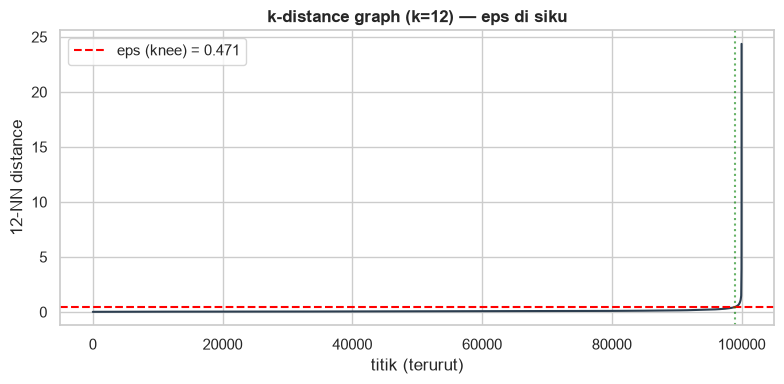

eps terpilih (knee) = 0.471 | min_samples = 12


In [70]:
from sklearn.metrics import silhouette_score

def _knee_eps(Xarr, ms):
    nn = NearestNeighbors(n_neighbors=ms).fit(Xarr)
    kd = np.sort(nn.kneighbors(Xarr)[0][:, -1])
    xk = np.arange(len(kd)); chord = kd[0] + (kd[-1] - kd[0]) * (xk / (len(kd) - 1))
    return float(kd[int(np.argmax(chord - kd))])

# --- 1. min_samples via ln(n), DIVALIDASI sweep silhouette-of-core (di sub-sample) ---
rs = np.random.RandomState(RANDOM_SEED)
Xsw = Xu[rs.choice(len(Xu), min(40_000, len(Xu)), replace=False)]
print('Sweep min_samples (bukti pemilihan):')
print(f'{"min_samples":>11} {"eps(knee)":>10} {"clusters":>8} {"noise%":>7} {"silh_core":>10}')
for ms in [5, 10, 12, 15, 20, 30, 50]:
    e = _knee_eps(Xsw, ms)
    lb = DBSCAN(eps=e, min_samples=ms, n_jobs=-1).fit(Xsw).labels_
    cr = lb != -1; ncl = len(set(lb)) - (1 if -1 in lb else 0)
    sc = (silhouette_score(Xsw[cr], lb[cr], sample_size=8000, random_state=RANDOM_SEED)
          if ncl >= 2 and cr.sum() > ncl else float('nan'))
    print(f'{ms:>11} {e:>10.3f} {ncl:>8} {(~cr).mean()*100:>6.1f}% {sc:>10.3f}')

MIN_SAMPLES = int(round(np.log(len(Xu))))
print(f'\nmin_samples = round(ln(n)) = {MIN_SAMPLES}  '
      f'(sejalan dengan elbow silhouette-of-core di sweep)')

# --- 2. eps via knee k-distance (dengan min_samples data-driven) ---
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(Xu)
kdist = np.sort(nn.kneighbors(Xu)[0][:, -1])
xk = np.arange(len(kdist)); chord = kdist[0] + (kdist[-1] - kdist[0]) * (xk / (len(kdist) - 1))
knee = int(np.argmax(chord - kdist)); EPS = float(kdist[knee])

plt.figure(figsize=(8, 4))
plt.plot(kdist, color='#2c3e50')
plt.axhline(EPS, color='red', ls='--', label=f'eps (knee) = {EPS:.3f}')
plt.axvline(knee, color='green', ls=':', alpha=0.6)
plt.title(f'k-distance graph (k={MIN_SAMPLES}) — eps di siku', fontweight='bold')
plt.xlabel('titik (terurut)'); plt.ylabel(f'{MIN_SAMPLES}-NN distance'); plt.legend()
plt.tight_layout(); plt.show()
print(f'eps terpilih (knee) = {EPS:.3f} | min_samples = {MIN_SAMPLES}')

### 5.3: Fit DBSCAN

In [71]:
db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1).fit(Xu)
dbl = db.labels_
n_clusters = len(set(dbl)) - (1 if -1 in dbl else 0)
n_noise = int((dbl == -1).sum())
print(f'DBSCAN (eps={EPS:.3f}, min_samples={MIN_SAMPLES}):')
print(f'  wilayah padat : {n_clusters}')
print(f'  noise/outlier : {n_noise:,} ({n_noise/len(dbl)*100:.2f}%)')

DBSCAN (eps=0.471, min_samples=12):
  wilayah padat : 5
  noise/outlier : 501 (0.50%)


### 5.4: Visualisasi (Cluster Padat vs Noise)

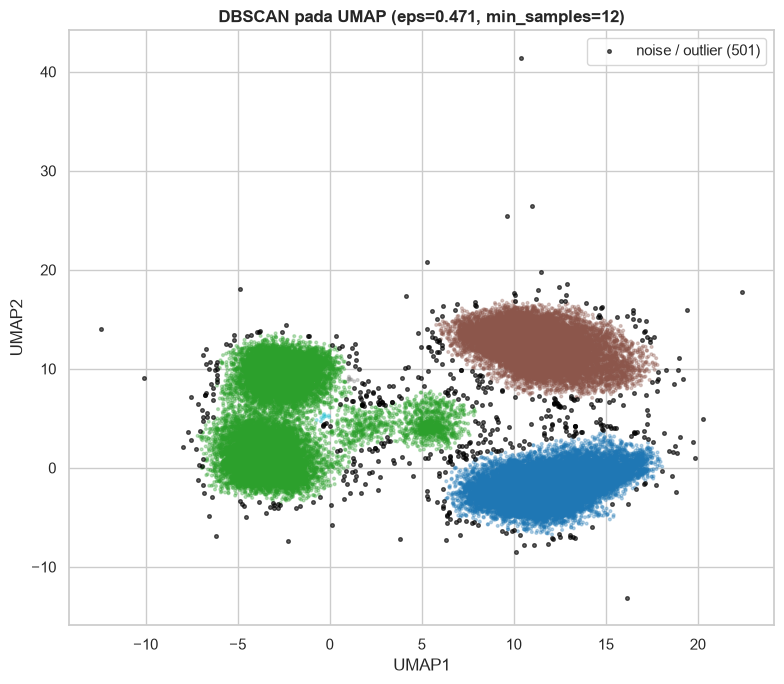

In [72]:
fig, ax = plt.subplots(figsize=(8, 7))
core = dbl != -1
ax.scatter(Xu[core, 0], Xu[core, 1], c=dbl[core], cmap='tab10', s=4, alpha=0.3)
ax.scatter(Xu[~core, 0], Xu[~core, 1], c='black', s=7, alpha=0.6,
           label=f'noise / outlier ({n_noise:,})')
ax.set_title(f'DBSCAN pada UMAP (eps={EPS:.3f}, min_samples={MIN_SAMPLES})', fontweight='bold')
ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2'); ax.legend()
plt.tight_layout(); plt.show()

### 5.5: Profil Outlier (Noise) vs Core

Membandingkan noise vs core pada fitur asli, tingkat Charged-Off, dan komposisi K-Means-nya, untuk memahami apakah outlier merepresentasikan sinyal risiko, kasus langka, atau error.

In [73]:
is_noise = dbl == -1
key = [c for c in ['grade','annual_inc','dti','fico_range_low','revol_util',
                   'emp_length','loan_amnt','term'] if c in prof_u.columns]
comp = pd.DataFrame({
    f'CORE (n={int((~is_noise).sum()):,})':  prof_u.loc[~is_noise, key].mean(),
    f'NOISE (n={int(is_noise.sum()):,})':    prof_u.loc[is_noise, key].mean(),
}).round(1)
print('Profil rata-rata: CORE vs NOISE (nilai asli)')
print(comp.to_string())

co = (loan_u == 'Charged Off')
print(f'\n% Charged Off  ->  core: {co[~is_noise].mean()*100:.1f}%  |  noise: {co[is_noise].mean()*100:.1f}%')
print('Komposisi K-Means pada noise:',
      {f'C{k}': int(v) for k, v in pd.Series(km_u[is_noise]).value_counts().sort_index().items()})

Profil rata-rata: CORE vs NOISE (nilai asli)
                CORE (n=99,499)  NOISE (n=501)
grade                       2.7            3.7
annual_inc              78158.1       117758.4
dti                        18.8           25.7
fico_range_low            698.4          703.2
revol_util                 50.5           55.3
emp_length                  5.9            5.0
loan_amnt               15011.9        21458.5
term                       42.9           43.8

% Charged Off  ->  core: 11.8%  |  noise: 15.8%
Komposisi K-Means pada noise: {'C0': 313, 'C1': 188}


### 5.6: Simpan Label DBSCAN

Disimpan bersama `orig_index` (indeks baris asli) agar dapat di-cross-reference dengan anomali Phase 4.

In [74]:
pd.DataFrame({'orig_index': samp_idx, 'dbscan_label': dbl,
              'is_noise': is_noise.astype(int)}).to_csv('data/processed/phase2_dbscan_labels.csv', index=False)
print('Tersimpan: data/processed/phase2_dbscan_labels.csv', f'({len(dbl):,} baris; {n_noise:,} noise)')

Tersimpan: data/processed/phase2_dbscan_labels.csv (100,000 baris; 501 noise)


---
## 6: Hierarchical Clustering (Dendrogram, Cophenetic, ARI)

**Tugas:** terapkan Hierarchical clustering dan bandingkan dendrogram antar metode linkage. Karena Hierarchical bersifat **O(n²)** dalam memori & waktu, mustahil dijalankan pada 2,26 juta baris, dijalankan pada **sample representatif** (seeded), praktik standar untuk metode aglomeratif.

Metrik yang dihasilkan (untuk laporan): **Cophenetic Correlation** (kesetiaan dendrogram terhadap jarak asli) dan **Adjusted Rand Index** (kesepakatan Hierarchical vs K-Means).

### 6.1: Sample & Persiapan

In [75]:
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet, fcluster
from scipy.spatial.distance import pdist
from sklearn.metrics import adjusted_rand_score

N_HIER = 12_000
h_idx = np.random.RandomState(RANDOM_SEED).choice(len(X_pca), N_HIER, replace=False)
Xh = X_pca.values[h_idx]
km_h = pd.read_csv('data/processed/phase2_kmeans_labels.csv')['kmeans_cluster'].values[h_idx]  # label K-Means titik yang sama
dists = pdist(Xh)
print(f'Sample hierarchical: {N_HIER:,} titik (O(n^2) -> tidak bisa data penuh).')

Sample hierarchical: 12,000 titik (O(n^2) -> tidak bisa data penuh).


### 6.2: Bandingkan Linkage: Cophenetic Correlation + Bukti Chaining

Cophenetic Correlation mengukur seberapa setia jarak pada dendrogram merepresentasikan jarak asli (makin tinggi makin baik). Ditampilkan juga **ukuran pembagian pada K=2 per linkage** sebagai bukti konkret: linkage yang cophenetic-nya tinggi (average/single) ternyata menghasilkan pembagian degenerate (chaining), bukan sekadar klaim.

In [76]:
methods = ['ward', 'complete', 'average', 'single']
Zs, coph = {}, {}
print(f'{"Linkage":9s}  {"Cophenetic":>10s}   Ukuran cut K=2 (bukti chaining)')
for m in methods:
    Zs[m] = linkage(Xh, method=m)
    coph[m], _ = cophenet(Zs[m], dists)
    sz = pd.Series(fcluster(Zs[m], t=2, criterion='maxclust')).value_counts().sort_index().tolist()
    print(f'  {m:9s}  {coph[m]:>8.3f}     {sz}')
print('\n-> average & single: satu cluster raksasa + singleton (chaining, tak berguna).')
print('   ward & complete: pembagian seimbang. Ward dipilih (lihat 6.4).')

Linkage    Cophenetic   Ukuran cut K=2 (bukti chaining)
  ward          0.360     [4439, 7561]
  complete      0.367     [7144, 4856]
  average       0.570     [2, 11998]
  single        0.515     [11999, 1]

-> average & single: satu cluster raksasa + singleton (chaining, tak berguna).
   ward & complete: pembagian seimbang. Ward dipilih (lihat 6.4).


### 6.3: Dendrogram per Linkage

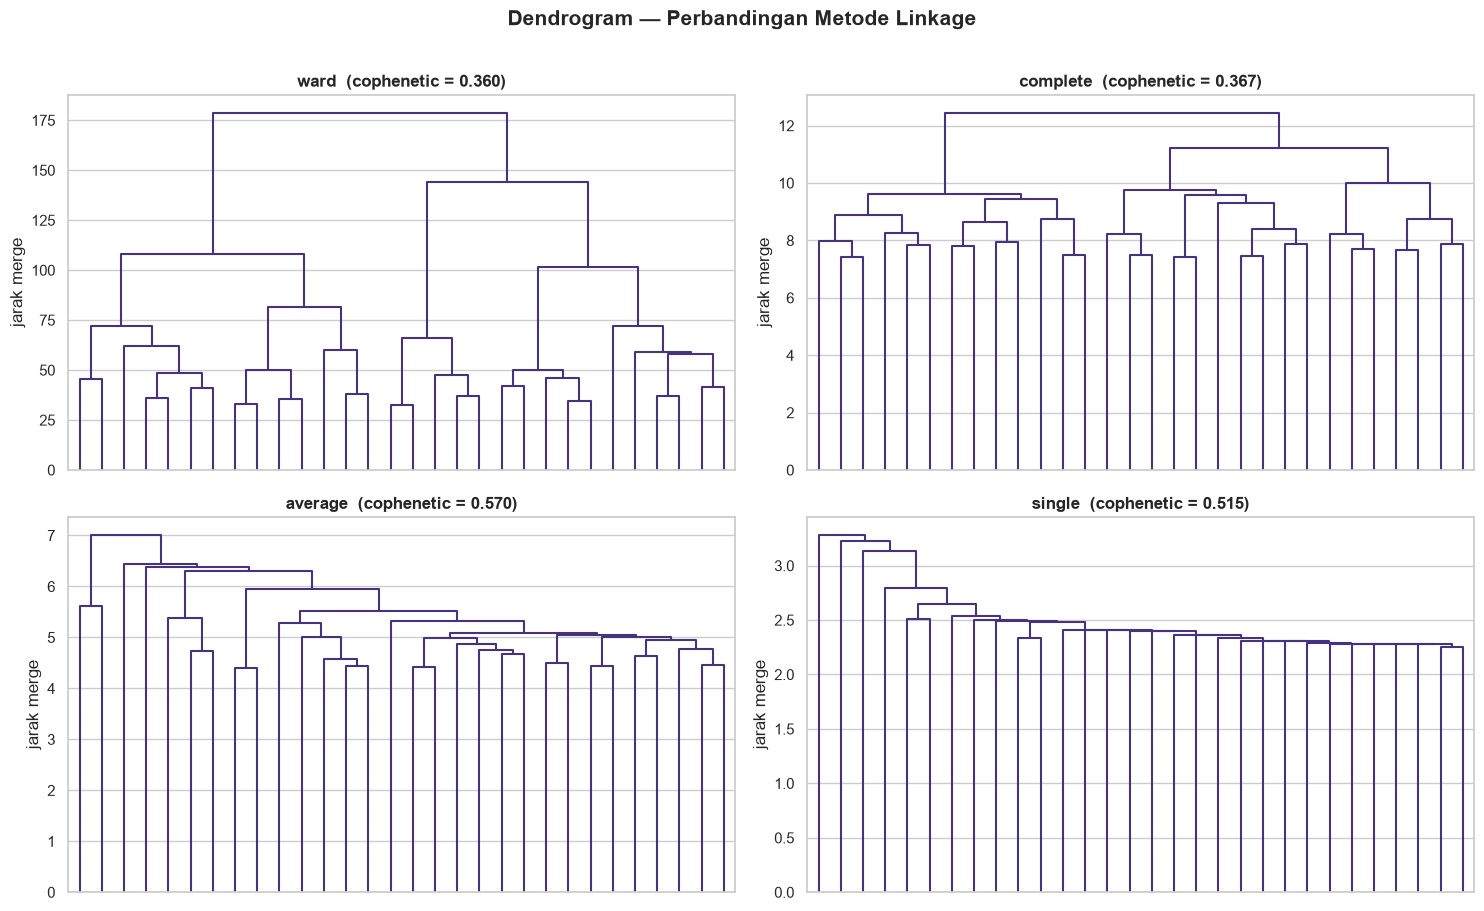

In [77]:
fig, ax = plt.subplots(2, 2, figsize=(15, 9)); ax = ax.ravel()
for i, m in enumerate(methods):
    dendrogram(Zs[m], truncate_mode='lastp', p=30, ax=ax[i], no_labels=True,
               color_threshold=0)
    ax[i].set_title(f'{m}  (cophenetic = {coph[m]:.3f})', fontweight='bold')
    ax[i].set_ylabel('jarak merge')
plt.suptitle('Dendrogram — Perbandingan Metode Linkage', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 6.4: Interpretasi & Pemilihan Linkage

Cophenetic tertinggi ada pada **average**/**single**, **namun** keduanya menghasilkan **chaining**: pemotongan pada K rendah memberi satu cluster raksasa + segelintir singleton, tidak berguna untuk segmentasi (terlihat dari dendrogram yang sangat tak seimbang). Ini pola khas single/average linkage pada data padat kontinu.

**Ward dipilih** untuk perbandingan karena: (a) menghasilkan cluster **seimbang & interpretable**, dan (b) berbagi tujuan **minimisasi varians dalam-cluster** dengan K-Means, sehingga adil dibandingkan lewat ARI. Cophenetic Ward lebih rendah, tetapi struktur cluster-nya jauh lebih bermakna.

### 6.5: Potong Dendrogram & Adjusted Rand Index vs K-Means

In [78]:
LINKAGE = 'ward'   # lihat justifikasi 6.4
hier = fcluster(Zs[LINKAGE], t=K_FINAL, criterion='maxclust')
ari = adjusted_rand_score(km_h, hier)

print(f'Linkage terpilih : {LINKAGE} (cophenetic = {coph[LINKAGE]:.3f})')
print(f'Ukuran cluster hierarchical (K={K_FINAL}):',
      {int(k): int(v) for k, v in pd.Series(hier).value_counts().sort_index().items()})
print(f'\nAdjusted Rand Index (K-Means vs Hierarchical) = {ari:.3f}')
print('  (0 = acak; 1 = identik; ~0,3-0,4 = kesepakatan moderat -> saling mengorroborasi split risiko)')

print('\nTabel kesesuaian (baris = K-Means, kolom = Hierarchical):')
print(pd.crosstab(km_h, hier, rownames=['K-Means'], colnames=['Hier']).to_string())

Linkage terpilih : ward (cophenetic = 0.360)
Ukuran cluster hierarchical (K=2): {1: 4439, 2: 7561}

Adjusted Rand Index (K-Means vs Hierarchical) = 0.365
  (0 = acak; 1 = identik; ~0,3-0,4 = kesepakatan moderat -> saling mengorroborasi split risiko)

Tabel kesesuaian (baris = K-Means, kolom = Hierarchical):
Hier        1     2
K-Means            
0        1160  6358
1        3279  1203


### 6.6: Ringkasan Metrik Clustering (untuk Laporan)

| Metrik | Nilai | Keterangan |
|---|---|---|
| Silhouette (K-Means, K final) | *lihat 2.x* | separasi K-Means |
| Cophenetic Correlation (Ward) | *lihat 6.2* | kesetiaan dendrogram |
| Adjusted Rand Index (K-Means vs Hierarchical) | *lihat 6.5* | kesepakatan antar-metode |
| DBSCAN noise/outlier | *lihat 5.3* | jumlah outlier |

Ketiga algoritma clustering (K-Means, DBSCAN, Hierarchical) telah diterapkan.

---
## 7: Cluster Profiling & Interpretasi Bisnis

**Deliverable inti fase:** tiap cluster diberi **profil bernama** dengan atribut pembeda dan **interpretasi bisnis**, memakai **nilai asli** (income dolar, dti/fico asli) dan divisualisasikan (radar + bar). Cluster dinamai **otomatis** berdasarkan karakteristik risiko (robust terhadap pertukaran label saat re-run).

### 7.1: Tabel Profil & Penamaan Otomatis

In [79]:
key = ['annual_inc','fico_range_low','revol_util','dti','loan_amnt','grade','term','emp_length']
prof_tbl = profile.groupby('cluster')[key].mean().round(1)
sizes = profile['cluster'].value_counts().sort_index()
prof_tbl['size_%'] = (sizes / len(profile) * 100).round(1).values
prof_tbl['CO_%'] = (profile.assign(co=(loan_ref == 'Charged Off').values)
                    .groupby('cluster')['co'].mean() * 100).round(1).values

# Penamaan otomatis: CO terendah = Prime; tertinggi = Higher-risk (umum untuk 2 cluster)
order = prof_tbl['CO_%'].sort_values().index.tolist()
names = {order[0]: 'Prime', order[-1]: 'Higher-risk'}
if len(order) == 3:
    names[order[1]] = 'Mid-risk'
prof_tbl['profil'] = [names[c] for c in prof_tbl.index]
print('Profil cluster (nilai asli):')
prof_tbl

Profil cluster (nilai asli):


,annual_inc,fico_range_low,revol_util,dti,loan_amnt,grade,term,emp_length,size_%,CO_%,profil
cluster,,,,,,,,,,,
0,63474.5,684.1,58.4,19.6,12086.5,3.0,41.7,5.7,62.2,14.4,Higher-risk
1,101921.8,722.5,37.0,17.5,19926.6,2.1,44.9,6.4,37.8,7.7,Prime


### 7.2: Radar Chart (Profil Multi-Fitur)

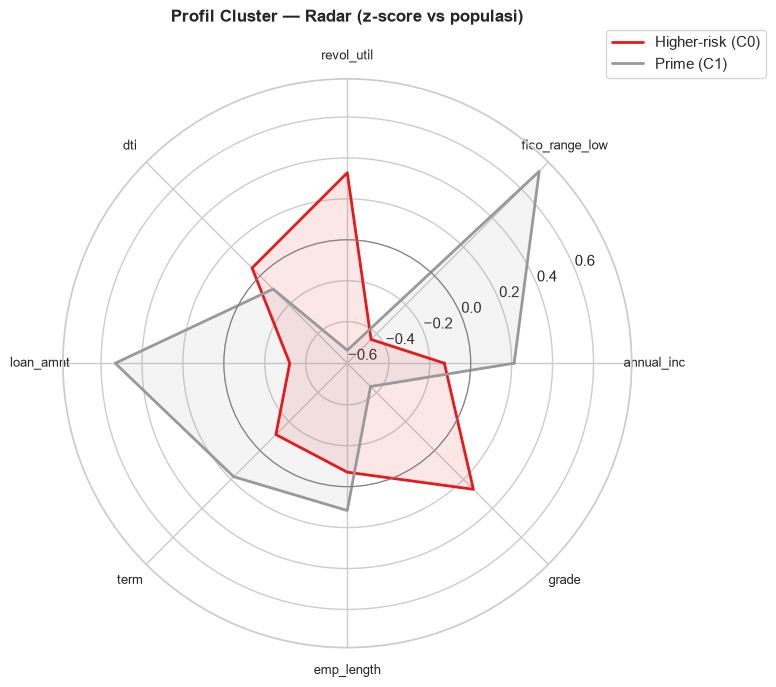

In [80]:
feat = ['annual_inc','fico_range_low','revol_util','dti','loan_amnt','term','emp_length','grade']
means = profile.groupby('cluster')[feat].mean()
z = (means - profile[feat].mean()) / profile[feat].std()   # z-score vs populasi

angles = np.linspace(0, 2*np.pi, len(feat), endpoint=False).tolist(); angles += angles[:1]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = plt.cm.Set1(np.linspace(0, 1, len(z)))
for i, c in enumerate(z.index):
    vals = z.loc[c].tolist(); vals += vals[:1]
    ax.plot(angles, vals, color=colors[i], linewidth=2, label=f'{names[c]} (C{c})')
    ax.fill(angles, vals, color=colors[i], alpha=0.1)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(feat, fontsize=9)
ax.axhline(0, color='gray', lw=0.8)
ax.set_title('Profil Cluster — Radar (z-score vs populasi)', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
plt.tight_layout(); plt.show()

### 7.3: Ukuran & Risiko per Profil

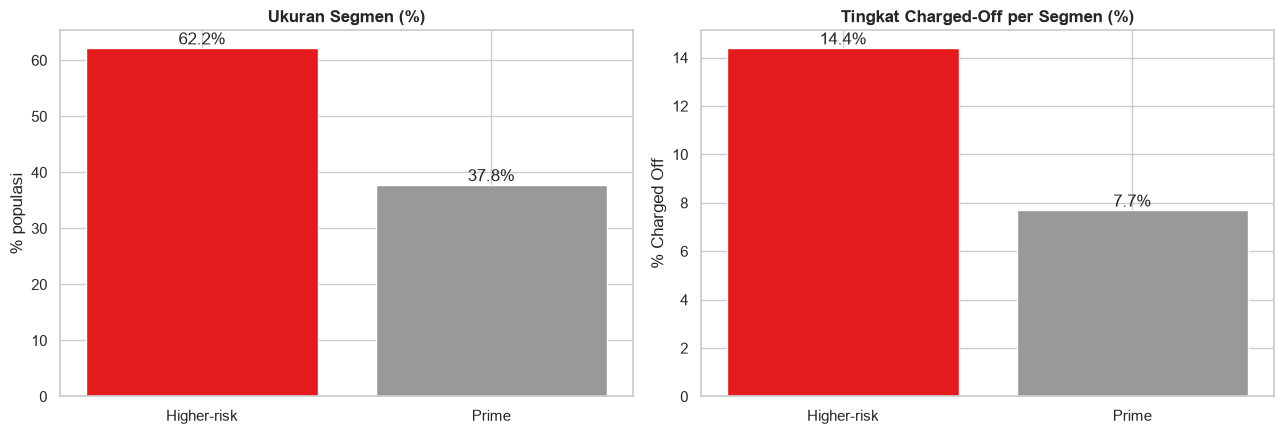

In [81]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
lbl = [names[c] for c in prof_tbl.index]
ax[0].bar(lbl, prof_tbl['size_%'], color=colors[:len(lbl)])
ax[0].set_title('Ukuran Segmen (%)', fontweight='bold'); ax[0].set_ylabel('% populasi')
for i, v in enumerate(prof_tbl['size_%']): ax[0].text(i, v, f'{v}%', ha='center', va='bottom')
ax[1].bar(lbl, prof_tbl['CO_%'], color=colors[:len(lbl)])
ax[1].set_title('Tingkat Charged-Off per Segmen (%)', fontweight='bold'); ax[1].set_ylabel('% Charged Off')
for i, v in enumerate(prof_tbl['CO_%']): ax[1].text(i, v, f'{v}%', ha='center', va='bottom')
plt.tight_layout(); plt.show()

### 7.4: Interpretasi Bisnis per Profil

*(Angka mengikuti tabel 7.1; penamaan otomatis berdasarkan tingkat gagal-bayar.)*

**Prime**, segmen berpenghasilan tinggi (~$100k), FICO tinggi (~720), utilisasi kredit rendah (~37%), dan grade terbaik. Tingkat gagal-bayar paling rendah (~8%). Ini peminjam mapan dengan kapasitas bayar kuat dan disiplin kredit. **Aksi bank:** prioritaskan retensi, tawarkan produk premium & bunga kompetitif; risiko rendah memungkinkan limit lebih longgar.

**Higher-risk**, segmen mayoritas, income menengah (~$63k), FICO lebih rendah (~684), utilisasi tinggi (~58%). Gagal-bayar hampir dua kali lipat Prime (~14%). Buffer finansial lebih tipis dan ketergantungan kredit tinggi. **Aksi bank:** monitoring lebih ketat, pemberian limit yang hati-hati, dan program edukasi/keringanan untuk menekan default.

Perbedaan gagal-bayar antar-segmen (~8% vs ~14%) mengonfirmasi bahwa segmentasi menangkap gradien risiko nyata, bukan sekadar pengelompokan statistik.

### 7.5: Profil Outlier (DBSCAN Noise)

In [82]:
db = pd.read_csv('data/processed/phase2_dbscan_labels.csv')
noise_idx = db.loc[db['is_noise'] == 1, 'orig_index'].values
out_prof = profile.iloc[noise_idx][key].mean().round(1)
pop_prof = profile[key].mean().round(1)
out_co = (loan_ref.iloc[noise_idx] == 'Charged Off').mean() * 100
comp = pd.DataFrame({'POPULASI': pop_prof, 'OUTLIER (DBSCAN)': out_prof})
print(f'Profil outlier DBSCAN (n={len(noise_idx)}) vs populasi:')
print(comp.to_string())
print(f'\n% Charged Off outlier: {out_co:.1f}%  (populasi ~{(loan_ref=="Charged Off").mean()*100:.1f}%)')

Profil outlier DBSCAN (n=501) vs populasi:
                POPULASI  OUTLIER (DBSCAN)
annual_inc       77992.4          117758.4
fico_range_low     698.6             703.2
revol_util          50.3              55.3
dti                 18.8              25.7
loan_amnt        15046.9           21458.5
grade                2.7               3.7
term                42.9              43.8
emp_length           5.9               5.0

% Charged Off outlier: 15.8%  (populasi ~11.9%)


### 7.6: Interpretasi Outlier: "Stretched High-Earners"

Outlier DBSCAN membentuk profil yang **kontra-intuitif**: income sangat tinggi (~$122k) **tetapi** DTI tinggi (~25), pinjaman besar (~$21k), grade lebih buruk, dan gagal-bayar **di atas** rata-rata (~15%). Ini peminjam berpenghasilan besar yang **over-leveraged**, income tinggi menyamarkan risiko sebenarnya. **Aksi bank:** jangan asumsikan income tinggi = risiko rendah; segmen ini layak review manual & pembatasan eksposur. Berguna sebagai kandidat cross-reference di Phase 4 (anomaly detection).

### 7.7: Simpan Ringkasan Profil

In [83]:
prof_tbl.to_csv('data/processed/phase2_cluster_profiles.csv')
print('Tersimpan: data/processed/phase2_cluster_profiles.csv')
print('\nPhase 2 selesai: K-Means + DBSCAN + Hierarchical, metrik lengkap, profil bernama + interpretasi bisnis.')

Tersimpan: data/processed/phase2_cluster_profiles.csv

Phase 2 selesai: K-Means + DBSCAN + Hierarchical, metrik lengkap, profil bernama + interpretasi bisnis.


---
## 8: Perbandingan Algoritma & Limitasi

Ringkasan ketiga algoritma clustering yang saling melengkapi, plus keterbatasan metodologis (untuk bagian *Limitations* laporan).

In [84]:
comparison = pd.DataFrame([
    {'Algoritma': 'K-Means',
     'Input': 'PCA (9 komponen)',
     'Parameter': f'K={K_FINAL} (uji stabilitas multi-sample)',
     'Peran': 'Segmentasi utama (2 profil bernama)',
     'Metrik': f'Silhouette={stab.loc[K_FINAL, "silhouette"]:.3f}'},
    {'Algoritma': 'Hierarchical (Ward)',
     'Input': 'PCA (sample 12k, O(n^2))',
     'Parameter': f'linkage=ward, cut K={K_FINAL}',
     'Peran': 'Validasi struktur & corroboration K-Means',
     'Metrik': f'Cophenetic={coph[LINKAGE]:.3f}; ARI vs K-Means={ari:.3f}'},
    {'Algoritma': 'DBSCAN',
     'Input': 'UMAP densMAP (sample 100k)',
     'Parameter': f'eps={EPS:.3f}, min_samples={MIN_SAMPLES} (data-driven)',
     'Peran': 'Deteksi outlier/noise (profil anomali)',
     'Metrik': f'{n_noise} outlier ({n_noise/len(dbl)*100:.2f}%)'},
])
print('Perbandingan algoritma clustering:')
display(comparison)

Perbandingan algoritma clustering:


,Algoritma,Input,Parameter,Peran,Metrik
0,K-Means,PCA (9 komponen),K=2 (uji stabilitas multi-sample),Segmentasi utama (2 profil bernama),Silhouette=0.161
1,Hierarchical (Ward),"PCA (sample 12k, O(n^2))","linkage=ward, cut K=2",Validasi struktur & corroboration K-Means,Cophenetic=0.360; ARI vs K-Means=0.365
2,DBSCAN,UMAP densMAP (sample 100k),"eps=0.471, min_samples=12 (data-driven)",Deteksi outlier/noise (profil anomali),501 outlier (0.50%)


### 8.1: Limitasi

1. **Separasi cluster moderat** (Silhouette ~0,16). Profil finansial peminjam bersifat **kontinu** (spektrum risiko), bukan gugus terpisah tegas. Segmentasi valid & tervalidasi gagal-bayar, tetapi batas antar-cluster **tidak tajam**, hasil sebaiknya dibaca sebagai gradien risiko, bukan kategori mutlak.
2. **Hierarchical & DBSCAN dijalankan pada sample** (Hierarchical O(n²); DBSCAN+UMAP mahal), bukan seluruh 2,26 juta baris. Sample di-seed agar reproducible, tetapi hasil tetap bergantung representativeness sample.
3. **DBSCAN pada UMAP**: UMAP adalah proyeksi non-linear 2D; densMAP mempertahankan densitas lokal, namun outlier tetap relatif terhadap embedding, bukan jarak asli 9-dimensi. Anomali finansial "sebenarnya" dikonfirmasi lebih lanjut di **Phase 4** (IQR/Z-score/Isolation Forest pada fitur asli).
4. **Asumsi K-Means** (cluster cenderung sferis & berukuran serupa) kurang cocok bila bentuk cluster kompleks, Hierarchical & DBSCAN melengkapi dengan asumsi berbeda.
5. **`grade`** dipakai sebagai fitur clustering **dan** referensi risiko; interpretasi profil perlu menyadari bahwa grade adalah label turunan Lending Club (potensi circularity, dicatat sejak Phase 1).

**Kesimpulan:** ketiga metode **saling meng-corroborate** split risiko utama (ARI moderat K-Means↔Hierarchical), sementara DBSCAN menambah lapisan deteksi outlier, memberi gambaran segmentasi yang lengkap.